📥 Executando a consulta SQL...


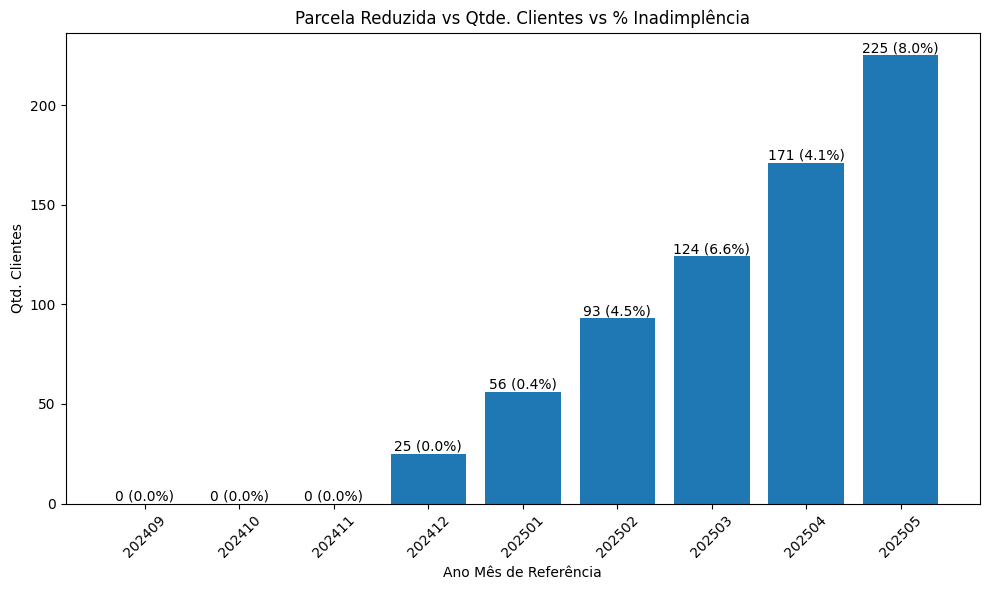

In [ ]:
# Bibliotecas utilizadas
import os
import pandas as pd
import pyodbc
import warnings
import matplotlib.pyplot as plt

# Pega usuário de rede
usuario = os.getenv('USERNAME')

# Tira mensagens de warning
warnings.filterwarnings('ignore')

# Caminho para o arquivo com credenciais
path = fr'C:\Users\{usuario}\OneDrive - CAIXA Consórcio\Documentos\SENHA_BANCO_DADOS'
os.chdir(path)

# Carrega credenciais
df_senhas = pd.read_excel('SENHAS.xlsx')
server, database, username, password = df_senhas.iloc[0, 0:4]

# Conexão com o SQL Server
conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}'
)

# Query SQL com filtros corretos e VL_Bem
query_table = """
SELECT 
    FT.AnoMesRef,
    FT.ID_UF,
    FT.Tipo_Pessoa,
    DP.CD_InscricaoNacional,
    RD.NM_Bem,
    FT.ST_Adimplencia,
    FT.VL_Bem
FROM 
    FT0015_CarteiraCotas AS FT
LEFT JOIN 
    DM0013_Pessoas AS DP ON FT.ID_Pessoa = DP.ID_Pessoa
LEFT JOIN 
    DM0011_Bens AS RD ON FT.ID_Bem = RD.ID_Bem
WHERE 
    FT.AnoMesRef >= '202410'
    AND RD.NM_Bem LIKE '%Reduzida%'
    AND FT.ST_Contemplacao = 'Contemplada'

"""

# Executa a consulta
print("📥 Executando a consulta SQL...")
df = pd.read_sql(query_table, conn)
conn.close()

# Garantir que os filtros estejam aplicados (reforço)
df = df[
    (df["AnoMesRef"] >= 202410) &
    (df["NM_Bem"].str.contains("Reduzida", case=False, na=False))
]

# Remove registros inválidos
df = df.dropna(subset=["CD_InscricaoNacional", "AnoMesRef", "VL_Bem", "ST_Adimplencia"])
df["AnoMesRef"] = df["AnoMesRef"].astype(int)

# Total de VL_Bem (base completa com os filtros)
vl_total = df.groupby("AnoMesRef")["VL_Bem"].sum().reset_index(name="VL_Bem_Total")

# Total de VL_Bem apenas dos inadimplentes (ST_Adimplencia = 'Inadimplente')
vl_inad = df[df["ST_Adimplencia"] == "Inadimplente"]
vl_inad_total = vl_inad.groupby("AnoMesRef")["VL_Bem"].sum().reset_index(name="VL_Bem_Inadimplente")

# Clientes distintos
clientes = df.groupby("AnoMesRef")["CD_InscricaoNacional"].nunique().reset_index(name="Qtd_Clientes")

# Unifica tudo
df_grouped = (
    clientes
    .merge(vl_total, on="AnoMesRef", how="left")
    .merge(vl_inad_total, on="AnoMesRef", how="left")
    .fillna(0)
)

# Calcula o percentual de inadimplência por valor
df_grouped["Perc_Inad"] = df_grouped.apply(
    lambda row: (row["VL_Bem_Inadimplente"] / row["VL_Bem_Total"] * 100) if row["VL_Bem_Total"] > 0 else 0,
    axis=1
)

# Completar meses desde 202410 até o último mês da base
min_ym = 202409
max_ym = df_grouped["AnoMesRef"].max()
ano_mes_completo = pd.date_range(
    start=f"{str(min_ym)[:4]}-{str(min_ym)[4:]}", 
    end=f"{str(max_ym)[:4]}-{str(max_ym)[4:]}", 
    freq="MS"
).strftime("%Y%m").astype(int)
df_completo = pd.DataFrame({"AnoMesRef": ano_mes_completo})

# Garantir todos os meses no gráfico
df_final = df_completo.merge(df_grouped, on="AnoMesRef", how="left").fillna(0)
df_final = df_final.astype({"Qtd_Clientes": int})

# Gráfico
plt.figure(figsize=(10, 6))
bars = plt.bar(df_final["AnoMesRef"].astype(str), df_final["Qtd_Clientes"])

# Rótulos com % de inadimplência por valor do bem
for bar, qtd, perc in zip(bars, df_final["Qtd_Clientes"], df_final["Perc_Inad"]):
    label = f"{qtd} ({perc:.1f}%)"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
             ha='center', va='bottom', fontsize=10)

plt.title("Parcela Reduzida vs Qtde. Clientes vs % Inadimplência")
plt.xlabel("Ano Mês de Referência")
plt.ylabel("Qtd. Clientes")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.grid(True)  ← Linha removida
plt.show()